In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import datetime

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    auc,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [2]:
dir = r"try_08"

x_train = pd.read_pickle(os.path.join(dir , "x_train.pkl"))
x_test = pd.read_pickle(os.path.join(dir , "x_test.pkl"))

y_train = pd.read_pickle(os.path.join(dir , "y_train.pkl"))
y_test = pd.read_pickle(os.path.join(dir , "y_test.pkl"))

rf1 = joblib.load(os.path.join(dir , "model_maxdepth10.pkl"))
rf2 = joblib.load(os.path.join(dir , "model_maxdepth35.pkl"))

In [3]:
models = {
    "RF_MaxDepth10": rf1,
    "RF_MaxDepth35": rf2
}

In [4]:
def compute_pr_curve(model, x_test, y_test):
    y_prob = model.predict_proba(x_test)[:, 1]
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    
    return y_prob, precision, recall, thresholds, pr_auc

In [5]:
def find_best_threshold(precision, recall, thresholds):
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    
    print("Best Threshold:", best_threshold)
    print("Best F1:", f1_scores[best_idx])
    
    return best_threshold, f1_scores

In [6]:
def plot_pr_curve(models_dict, x_test, y_test):
    plt.figure()
    
    for name, model in models_dict.items():
        y_prob = model.predict_proba(x_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        
        plt.plot(recall, precision, label=name)
    
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve Comparison")
    plt.legend()
    plt.show()

In [7]:
def evaluate_thresholds(y_prob, y_test, thresholds_list=[0.1 , 0.2 , 0.3 , 0.4 , 0.5]):
    
    for t in thresholds_list:
        print(f"\n===== Threshold: {t} =====")
        
        y_pred = (y_prob >= t).astype(int)
        
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))
        
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

In [8]:
def final_evaluation(y_prob, y_test, threshold):
    
    print("\n===== FINAL MODEL EVALUATION =====")
    print("\nBest Threshold:", threshold)
    
    y_pred = (y_prob >= threshold).astype(int)
    
    print("\n--- Overall Metrics ---")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("PR-AUC   :", average_precision_score(y_test, y_prob))
    
    print("\n--- Confusion Matrix ---")
    print(confusion_matrix(y_test, y_pred))
    
    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred))

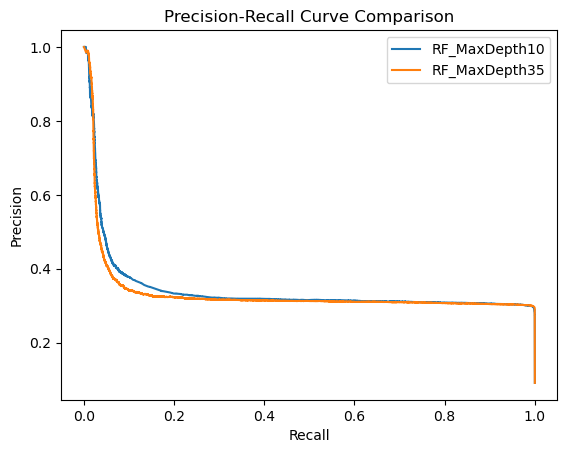

In [9]:
plot_pr_curve(models, x_test, y_test)

In [10]:
y_prob1, precision1, recall1, thresholds1, pr_auc1 = compute_pr_curve(rf1, x_test, y_test)
best_threshold1, _ = find_best_threshold(precision1, recall1, thresholds1)
print("\n")
y_prob2, precision2, recall2, thresholds2, pr_auc2 = compute_pr_curve(rf2, x_test, y_test)
best_threshold2, _ = find_best_threshold(precision2, recall2, thresholds2)

Best Threshold: 0.6974235978259319
Best F1: 0.4615492600169088


Best Threshold: 0.1665333527512696
Best F1: 0.46187008896020226


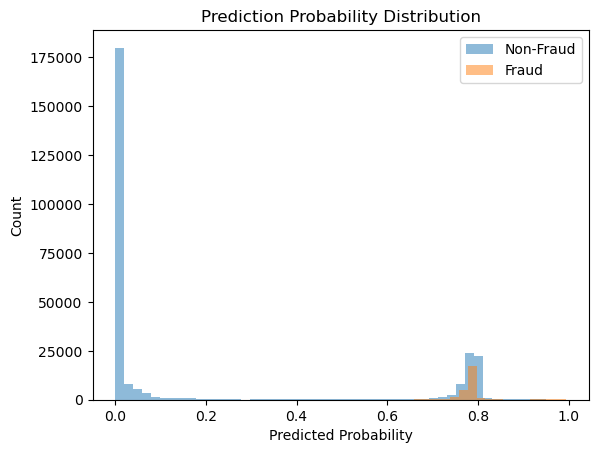

In [11]:
plt.figure()
plt.hist(y_prob1[y_test == 0], bins=50, alpha=0.5, label="Non-Fraud")
plt.hist(y_prob1[y_test == 1], bins=50, alpha=0.5, label="Fraud")
plt.legend()
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

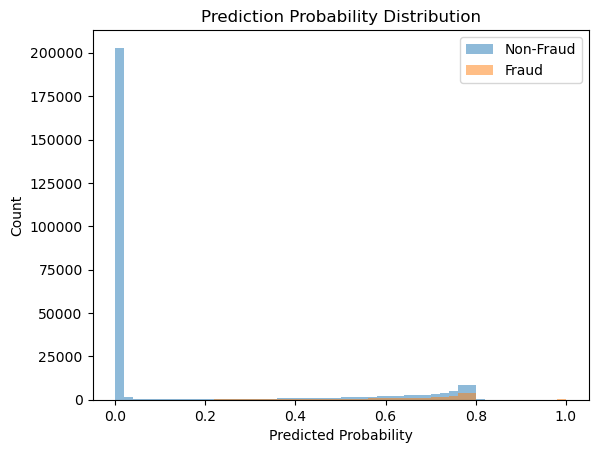

In [12]:
plt.figure()
plt.hist(y_prob2[y_test == 0], bins=50, alpha=0.5, label="Non-Fraud")
plt.hist(y_prob2[y_test == 1], bins=50, alpha=0.5, label="Fraud")
plt.legend()
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

In [13]:
# evaluate_thresholds(y_prob1, y_test)

In [14]:
# evaluate_thresholds(y_prob2, y_test)

In [16]:
final_evaluation(y_prob1, y_test, best_threshold1)


===== FINAL MODEL EVALUATION =====

Best Threshold: 0.6974235978259319

--- Overall Metrics ---
Accuracy : 0.79256899996957
Precision: 0.30249761282974585
Recall   : 0.9733111234499352
F1 Score : 0.4615492636346083
PR-AUC   : 0.3425998895550544

--- Confusion Matrix ---
[[208117  60629]
 [   721  26294]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.77      0.87    268746
           1       0.30      0.97      0.46     27015

    accuracy                           0.79    295761
   macro avg       0.65      0.87      0.67    295761
weighted avg       0.93      0.79      0.83    295761



In [17]:
final_evaluation(y_prob2, y_test, best_threshold2)


===== FINAL MODEL EVALUATION =====

Best Threshold: 0.1665333527512696

--- Overall Metrics ---
Accuracy : 0.7898269210612623
Precision: 0.301430540803182
Recall   : 0.9874514158800666
F1 Score : 0.4618700925436964
PR-AUC   : 0.33454537855159105

--- Confusion Matrix ---
[[206924  61822]
 [   339  26676]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.77      0.87    268746
           1       0.30      0.99      0.46     27015

    accuracy                           0.79    295761
   macro avg       0.65      0.88      0.67    295761
weighted avg       0.93      0.79      0.83    295761



In [18]:
feature_importance = pd.DataFrame({
    "features": x_train.columns,
    "importance": rf1.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(32)

,features,importance
0,amount,0.355720
3,amount_balance_ratio,0.192898
4,balance_error_i,0.130795
6,INIT_AMOUNT_DEV_TX_6,0.086306
5,INIT_AVG_AMOUNT_TX_6,0.074321
8,INIT_AMOUNT_DEV_TX_12,0.052747
10,INIT_AMOUNT_DEV_TX_24,0.039131
7,INIT_AVG_AMOUNT_TX_12,0.033542
9,INIT_AVG_AMOUNT_TX_24,0.013510
1,oldBalInitiator,0.010906


In [19]:
feature_importance = pd.DataFrame({
    "features": x_train.columns,
    "importance": rf2.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(32)

,features,importance
0,amount,0.312758
3,amount_balance_ratio,0.174677
4,balance_error_i,0.116724
6,INIT_AMOUNT_DEV_TX_6,0.090300
5,INIT_AVG_AMOUNT_TX_6,0.077637
8,INIT_AMOUNT_DEV_TX_12,0.059055
10,INIT_AMOUNT_DEV_TX_24,0.047801
7,INIT_AVG_AMOUNT_TX_12,0.044384
9,INIT_AVG_AMOUNT_TX_24,0.029372
1,oldBalInitiator,0.024587
